# Best UniversalXAS and Tuned-UniversalXAS: all FEFF elements + VASP

This notebook compares the best UniversalXAS source and best tuned head for:

- custom scratch-encoder FEFF features: Ti, V, Cr, Mn, Fe, Co, Ni, Cu;
- custom scratch-encoder VASP features: Ti, Cu.

Checkpoint selection uses validation eta only. Test data is evaluated only for the selected UniversalXAS and tuned checkpoints.

## 1. Paths and configuration

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

from omnixas.data.ml_data import MLData, MLSplits
from omnixas.model.training import PlModule
from omnixas.model.xasblock import XASBlock

REPO_ROOT = Path.cwd().resolve()
while not ((REPO_ROOT / "pyproject.toml").exists() and (REPO_ROOT / "omnixas").exists()):
    if REPO_ROOT.parent == REPO_ROOT:
        raise FileNotFoundError("Run this notebook from inside the OmniXAS repo")
    REPO_ROOT = REPO_ROOT.parent

DEFAULT_ENCODER_RUN = REPO_ROOT.parent / "training071326" / "m3gnetAll8FEFF" / "scratch_temp_seed42"
ENCODER_RUN = Path(os.environ.get("OMNIXAS_ENCODER_RUN", DEFAULT_ENCODER_RUN)).expanduser().resolve()
FEATURES_DIR = ENCODER_RUN / "features"
TUNED_ROOT = ENCODER_RUN / "heads" / "tunedUniversalXAS"
RESULTS_DIR = ENCODER_RUN / "analysis" / "best_universal_tuned"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEFF_ELEMENTS = ["Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu"]
DATASETS = [f"{element}_FEFF" for element in FEFF_ELEMENTS] + ["Ti_VASP", "Cu_VASP"]
INPUT_DIM, OUTPUT_DIM = 64, 141
HIDDEN_DIMS = [500, 500, 550]
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

PAPER_EXPERT_TEST_ETA = {
    "Ti_FEFF": 6.35, "V_FEFF": 7.30, "Cr_FEFF": 8.54, "Mn_FEFF": 17.66,
    "Fe_FEFF": 7.51, "Co_FEFF": 14.47, "Ni_FEFF": 8.45, "Cu_FEFF": 5.19,
    "Ti_VASP": 4.75, "Cu_VASP": 8.46,
}
PAPER_UNIVERSAL_TEST_ETA = {
    "Ti_FEFF": 4.19, "V_FEFF": 5.19, "Cr_FEFF": 7.13, "Mn_FEFF": 13.15,
    "Fe_FEFF": 6.04, "Co_FEFF": 9.58, "Ni_FEFF": 6.43, "Cu_FEFF": 2.75,
}
PAPER_TUNED_TEST_ETA = {
    "Ti_FEFF": 7.63, "V_FEFF": 9.22, "Cr_FEFF": 10.44, "Mn_FEFF": 29.81,
    "Fe_FEFF": 8.98, "Co_FEFF": 19.83, "Ni_FEFF": 11.21, "Cu_FEFF": 4.81,
    "Ti_VASP": 5.27, "Cu_VASP": 9.21,
}

missing_custom_vasp = [
    FEATURES_DIR / f"{dataset}_{split_name}_X.txt"
    for dataset in ["Ti_VASP", "Cu_VASP"]
    for split_name in ["train", "val", "test"]
    if not (FEATURES_DIR / f"{dataset}_{split_name}_X.txt").exists()
]
if missing_custom_vasp:
    raise FileNotFoundError(
        f"Selected encoder run has no Ti/Cu VASP features: {ENCODER_RUN}"
    )


## 2. Load and validate data

In [2]:
def load_split(dataset: str, directory: Path) -> MLSplits:
    parts = {}
    for split_name in ["train", "val", "test"]:
        X = np.atleast_2d(np.loadtxt(directory / f"{dataset}_{split_name}_X.txt", dtype=np.float32))
        y = np.atleast_2d(np.loadtxt(directory / f"{dataset}_{split_name}_y.txt", dtype=np.float32))
        if len(X) != len(y) or X.shape[1] != INPUT_DIM or y.shape[1] != OUTPUT_DIM:
            raise ValueError(f"Invalid {dataset} {split_name} shapes: X={X.shape}, y={y.shape}")
        if not np.isfinite(X).all() or not np.isfinite(y).all():
            raise ValueError(f"Non-finite values in {dataset} {split_name}")
        parts[split_name] = MLData(X=X, y=y)
    return MLSplits(**parts)


splits = {
    dataset: load_split(dataset, FEATURES_DIR)
    for dataset in DATASETS
}

for dataset, split in splits.items():
    print(dataset, len(split.train), len(split.val), len(split.test))

Ti_FEFF 5140 641 641
V_FEFF 8653 1080 1080
Cr_FEFF 2457 305 305
Mn_FEFF 13644 1704 1704
Fe_FEFF 9657 1205 1205
Co_FEFF 8605 1074 1074
Ni_FEFF 3471 432 432
Cu_FEFF 3340 416 416
Ti_VASP 3030 377 377
Cu_VASP 2584 321 321


## 3. Discover checkpoints

In [3]:
def checkpoints(root: Path) -> list[Path]:
    return sorted(set(root.glob("*/best*.ckpt")) | set(root.glob("*/checkpoints/best*.ckpt")))


universal = checkpoints(ENCODER_RUN / "heads" / "universalXAS" / "All_FEFF" / "runs")
if not universal:
    raise FileNotFoundError("Missing custom scratch-encoder UniversalXAS checkpoint")

candidate_checkpoints = {}
for dataset in DATASETS:
    tuned = checkpoints(TUNED_ROOT / dataset / "runs")
    if not tuned:
        raise FileNotFoundError(
            f"Missing custom scratch-encoder tuned checkpoints for {dataset}. "
            "Do not substitute checkpoints trained in another encoder feature space."
        )
    candidate_checkpoints[dataset] = {"UniversalXAS": universal, "Tuned-UniversalXAS": tuned}
    print(dataset, "Universal:", len(universal), "tuned:", len(tuned))


Ti_FEFF Universal: 1 tuned: 4
V_FEFF Universal: 1 tuned: 4
Cr_FEFF Universal: 1 tuned: 37
Mn_FEFF Universal: 1 tuned: 35
Fe_FEFF Universal: 1 tuned: 4
Co_FEFF Universal: 1 tuned: 4
Ni_FEFF Universal: 1 tuned: 4
Cu_FEFF Universal: 1 tuned: 4
Ti_VASP Universal: 1 tuned: 2
Cu_VASP Universal: 1 tuned: 2


## 4. Select checkpoints by validation eta

In [4]:
def predict(checkpoint: Path, X: np.ndarray) -> np.ndarray:
    XASBlock.DROPOUT = 0.0
    module = PlModule.load_from_checkpoint(
        checkpoint_path=str(checkpoint),
        model=XASBlock(INPUT_DIM, HIDDEN_DIMS, OUTPUT_DIM),
        lr=1e-4,
    ).to(DEVICE).eval()
    loader = DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32)), batch_size=1024)
    with torch.inference_mode():
        batches = [module(batch[0].to(DEVICE)).cpu().numpy() for batch in loader]
    return np.concatenate(batches)


def eta_metrics(split: MLSplits, split_name: str, predictions: np.ndarray) -> dict[str, float]:
    targets = getattr(split, split_name).y
    mse = np.mean((targets - predictions) ** 2, axis=1)
    baseline = np.mean((targets - split.train.y.mean(axis=0, keepdims=True)) ** 2, axis=1)
    median_mse = float(np.median(mse))
    return {"eta": float(np.median(baseline)) / median_mse, "median_mse": median_mse}


validation_rows = []
for dataset in DATASETS:
    split = splits[dataset]
    for model_name, paths in candidate_checkpoints[dataset].items():
        for checkpoint in paths:
            metrics = eta_metrics(split, "val", predict(checkpoint, split.val.X))
            validation_rows.append({
                "dataset": dataset,
                "model": model_name,
                "checkpoint": str(checkpoint),
                "val_eta": metrics["eta"],
                "val_median_mse": metrics["median_mse"],
            })

validation_results = pd.DataFrame(validation_rows)
selected = (
    validation_results.sort_values(["dataset", "model", "val_eta"], ascending=[True, True, False])
    .groupby(["dataset", "model"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)
validation_results.to_csv(RESULTS_DIR / "all_validation_candidates.csv", index=False)
selected.to_csv(RESULTS_DIR / "selected_by_validation_eta.csv", index=False)

## 5. Evaluate selected checkpoints on test

In [5]:
final_rows = []
test_artifacts = {}
for dataset in DATASETS:
    split = splits[dataset]
    rows = selected[selected["dataset"].eq(dataset)].set_index("model")
    artifact = RESULTS_DIR / f"{dataset}_selected_test.npz"

    universal_checkpoint = Path(rows.loc["UniversalXAS", "checkpoint"])
    tuned_checkpoint = Path(rows.loc["Tuned-UniversalXAS", "checkpoint"])
    if artifact.exists():
        with np.load(artifact, allow_pickle=False) as cached:
            metrics = json.loads(str(cached["metrics_json"]))
        if (
            metrics["universal_checkpoint"] != str(universal_checkpoint)
            or metrics["tuned_checkpoint"] != str(tuned_checkpoint)
        ):
            raise RuntimeError(f"Selected checkpoint changed: {artifact}")
    else:
        universal_predictions = predict(universal_checkpoint, split.test.X)
        tuned_predictions = predict(tuned_checkpoint, split.test.X)
        universal_test = eta_metrics(split, "test", universal_predictions)
        tuned_test = eta_metrics(split, "test", tuned_predictions)
        metrics = {
            "universal_checkpoint": str(universal_checkpoint),
            "tuned_checkpoint": str(tuned_checkpoint),
            "universal_test_eta": universal_test["eta"],
            "tuned_test_eta": tuned_test["eta"],
        }
        np.savez_compressed(
            artifact,
            universal_mse=np.mean((split.test.y - universal_predictions) ** 2, axis=1),
            tuned_mse=np.mean((split.test.y - tuned_predictions) ** 2, axis=1),
            metrics_json=np.array(json.dumps(metrics)),
        )

    final_rows.append({
        "dataset": dataset,
        "feature_space": "scratch",
        "universal_val_eta": rows.loc["UniversalXAS", "val_eta"],
        "universal_test_eta": metrics["universal_test_eta"],
        "tuned_val_eta": rows.loc["Tuned-UniversalXAS", "val_eta"],
        "tuned_test_eta": metrics["tuned_test_eta"],
        "tuned_minus_universal_test_eta": metrics["tuned_test_eta"] - metrics["universal_test_eta"],
        "paper_expert_test_eta": PAPER_EXPERT_TEST_ETA[dataset],
        "paper_universal_test_eta": PAPER_UNIVERSAL_TEST_ETA.get(dataset, np.nan),
        "paper_tuned_test_eta": PAPER_TUNED_TEST_ETA[dataset],
        "tuned_minus_paper_test_eta": metrics["tuned_test_eta"] - PAPER_TUNED_TEST_ETA[dataset],
    })
    test_artifacts[dataset] = artifact

final_results = pd.DataFrame(final_rows)
table_results = final_results[final_results["dataset"].str.endswith("_FEFF")][[
    "dataset", "tuned_test_eta", "universal_test_eta",
    "paper_universal_test_eta", "paper_tuned_test_eta",
]].reset_index(drop=True)
table_results.to_csv(RESULTS_DIR / "best_universal_vs_tuned.csv", index=False)
display(table_results.style.format(precision=3))


,dataset,tuned_test_eta,universal_test_eta,paper_universal_test_eta,paper_tuned_test_eta
0,Ti_FEFF,9.790,9.531,4.190,7.630
1,V_FEFF,10.027,9.613,5.190,9.220
2,Cr_FEFF,16.284,15.201,7.130,10.440
3,Mn_FEFF,33.096,22.770,13.150,29.810
4,Fe_FEFF,12.827,11.695,6.040,8.980
5,Co_FEFF,23.392,20.733,9.580,19.830
6,Ni_FEFF,16.093,14.362,6.430,11.210
7,Cu_FEFF,6.305,5.422,2.750,4.810


## 6. Test-only plots

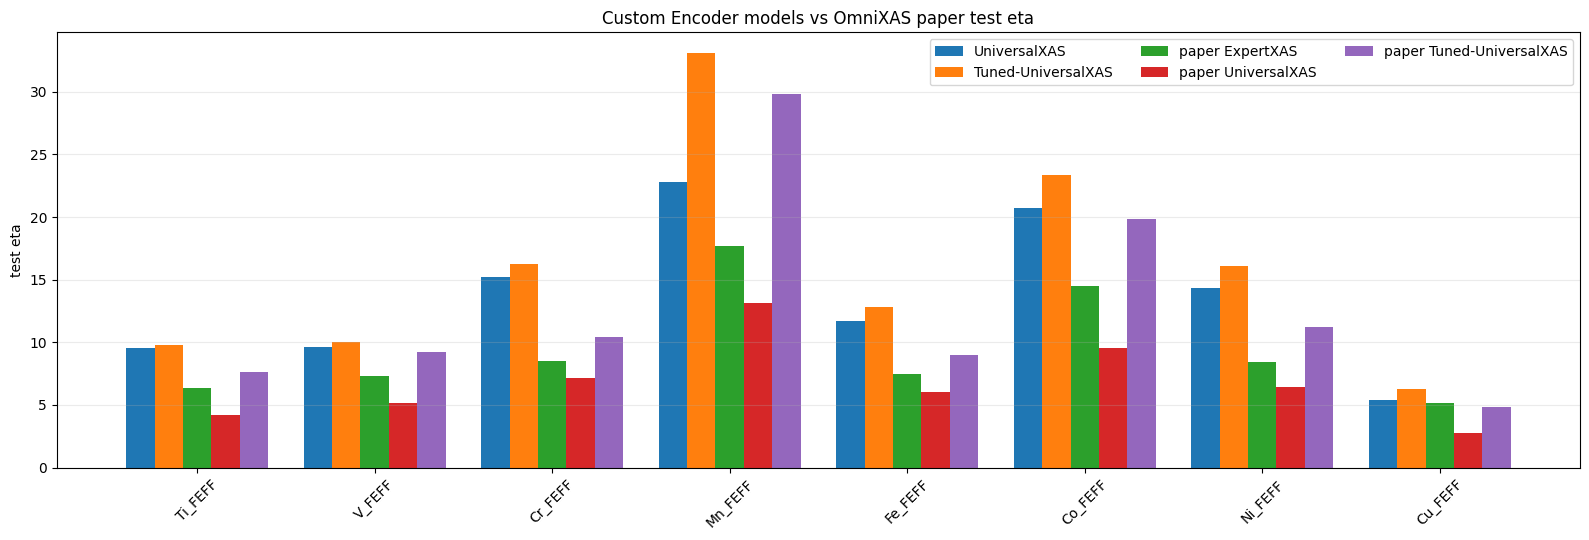

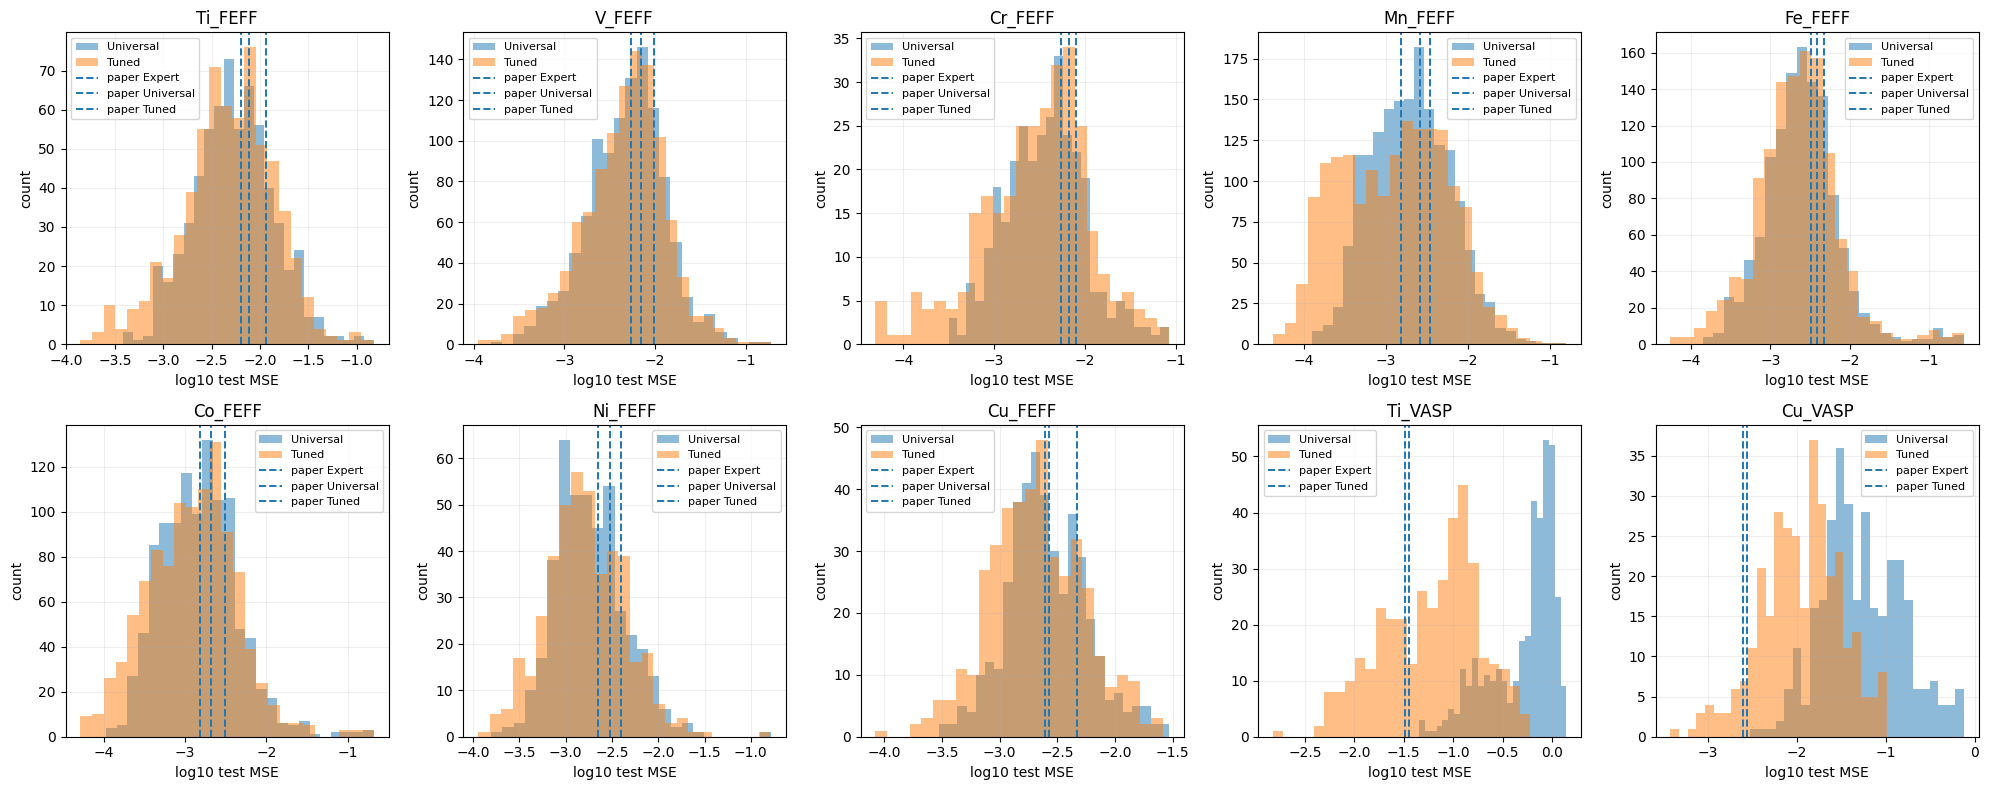

In [7]:
feff_results = final_results[final_results["dataset"].str.endswith("_FEFF")].reset_index(drop=True)
x = np.arange(len(feff_results))
series = [
    ("UniversalXAS", "universal_test_eta"),
    ("Tuned-UniversalXAS", "tuned_test_eta"),
    ("paper ExpertXAS", "paper_expert_test_eta"),
    ("paper UniversalXAS", "paper_universal_test_eta"),
    ("paper Tuned-UniversalXAS", "paper_tuned_test_eta"),
]
width = 0.16
fig, ax = plt.subplots(figsize=(16, 5.5))
for offset, (label, column) in zip(np.linspace(-2, 2, len(series)) * width, series):
    ax.bar(x + offset, feff_results[column], width, label=label)
ax.set(xticks=x, xticklabels=feff_results["dataset"], ylabel="test eta", title="Custom Encoder models vs OmniXAS paper test eta")
ax.tick_params(axis="x", rotation=45)
ax.legend(ncol=3)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "best_universal_vs_tuned_test_eta.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(20, 8), squeeze=False)
for ax, dataset in zip(axes.flat, DATASETS):
    with np.load(test_artifacts[dataset], allow_pickle=False) as cached:
        universal_mse = cached["universal_mse"]
        tuned_mse = cached["tuned_mse"]
    split = splits[dataset]
    baseline_mse = np.mean((split.test.y - split.train.y.mean(axis=0, keepdims=True)) ** 2, axis=1)
    baseline_median_mse = float(np.median(baseline_mse))
    paper_lines = [
        ("paper Expert", PAPER_EXPERT_TEST_ETA[dataset]),
        ("paper Universal", PAPER_UNIVERSAL_TEST_ETA.get(dataset, np.nan)),
        ("paper Tuned", PAPER_TUNED_TEST_ETA[dataset]),
    ]

    floor = np.finfo(np.float32).tiny
    ax.hist(np.log10(np.maximum(universal_mse, floor)), bins=25, alpha=0.50, label="Universal")
    ax.hist(np.log10(np.maximum(tuned_mse, floor)), bins=25, alpha=0.50, label="Tuned")
    for label, paper_eta in paper_lines:
        if np.isfinite(paper_eta):
            ax.axvline(np.log10(max(baseline_median_mse / paper_eta, floor)), linestyle="--", linewidth=1.4, label=label)
    ax.set(title=dataset, xlabel="log10 test MSE", ylabel="count")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "best_universal_vs_tuned_test_histograms.png", dpi=180, bbox_inches="tight")
plt.show()
